In [1]:
# ANALYZE FILES IN KAGGLE INPUT DIRECTORY

import numpy as np
import pandas as pd
import os

# Initialize counters
file_count = 0
file_extensions = {}

# Scan the input directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    file_count += len(filenames)
    for filename in filenames:
        # Get file extension
        ext = os.path.splitext(filename)[1].lower()
        file_extensions[ext] = file_extensions.get(ext, 0) + 1

# Print summary
print(f"Total files found: {file_count}")
print("\nFile extensions summary:")
for ext, count in sorted(file_extensions.items()):
    print(f"{ext if ext else 'No extension'}: {count} files")

Total files found: 2501

File extensions summary:
.jpeg: 138 files
.jpg: 2362 files
.keras: 1 files


In [2]:
# CHECKING FOR FILES AND DATASETS IN THE INPUT DIRECTORY


import shutil
import os

output_dir = "/kaggle/working"

# Instead of deleting the entire working directory,
# we'll just delete all files and subdirectories within it
for filename in os.listdir(output_dir):
    file_path = os.path.join(output_dir, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)
    except Exception as e:
        print(f'Failed to delete {file_path}. Reason: {e}')

print("✅ All files and folders in working directory deleted (if they existed).")

✅ All files and folders in working directory deleted (if they existed).


In [3]:
# Clear Kaggle Working Directory

# Run this before training to remove unused files
!rm -rf /kaggle/working/*

In [4]:
# Display Top 20 Largest Files in Kaggle Working Directory

# Run this command in a Kaggle notebook to see which files are using space:
!du -h /kaggle/working | sort -rh | head -20

4.0K	/kaggle/working


In [5]:
# Image Preprocessing and Metadata Generation

import os
import numpy as np
import pandas as pd
import cv2
from PIL import Image, ImageFile
from tqdm import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True

class Config:
    INPUT_DIR = "/kaggle/input/weather-dataset/newnewDataset"
    OUTPUT_DIR = "/kaggle/working/preprocessed"
    JPG_DIR = os.path.join(OUTPUT_DIR, "jpg_images")
    NPY_DIR = os.path.join(OUTPUT_DIR, "npy_arrays")
    METADATA_PATH = os.path.join(OUTPUT_DIR, "metadata.csv")
    VALIDATION_REPORT_PATH = os.path.join(OUTPUT_DIR, "validation_report.txt")
    TARGET_SIZE = (256, 256)
    GRAYSCALE = True
    
    # Folder to code and precipitation class mapping
    FOLDER_MAPPING = {
        "altocumulus": ("Ac", 1),
        "altostratus": ("As", 1),
        "cirrocumulus": ("Cc", 0),
        "cirrostratus": ("Cs", 0),
        "cirrus": ("Ci", 0),
        "cumulonimbus": ("Cb", 3),
        "cumulus": ("Cu", 1),
        "nimbostratus": ("Ns", 2),
        "stratocumulus": ("Sc", 1),
        "stratus": ("St", 1)
    }

def process_image(img_path):
    """Convert image to grayscale and resize"""
    with Image.open(img_path) as img:
        img = img.convert("L")  # Grayscale conversion
        img = img.resize(Config.TARGET_SIZE)
        img_array = np.array(img, dtype=np.float32) / 255.0
        img_array = cv2.GaussianBlur(img_array, (3, 3), sigmaX=1)
        return img_array

def create_metadata_and_preprocess():
    # Create output directories
    os.makedirs(Config.JPG_DIR, exist_ok=True)
    os.makedirs(Config.NPY_DIR, exist_ok=True)
    
    # Create subdirectories for each cloud type
    for folder_name in Config.FOLDER_MAPPING:
        os.makedirs(os.path.join(Config.JPG_DIR, folder_name), exist_ok=True)
        os.makedirs(os.path.join(Config.NPY_DIR, folder_name), exist_ok=True)
    
    metadata = []
    counts = {folder: 0 for folder in Config.FOLDER_MAPPING}

    print("Starting image processing...")
    
    for folder_name in tqdm(Config.FOLDER_MAPPING, desc="Processing Folders"):
        code, precip = Config.FOLDER_MAPPING[folder_name]
        input_folder = os.path.join(Config.INPUT_DIR, folder_name)
        
        if not os.path.exists(input_folder):
            print(f"\nWarning: Missing folder {folder_name}")
            continue
            
        img_files = [f for f in os.listdir(input_folder) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        print(f"\nProcessing {folder_name} ({code}): {len(img_files)} images")
        
        for img_file in tqdm(img_files, desc=folder_name, leave=False):
            try:
                img_path = os.path.join(input_folder, img_file)
                base_name = os.path.splitext(img_file)[0]
                
                # Process image
                img_array = process_image(img_path)
                
                # Save files (still saving both JPG and NPY)
                jpg_path = os.path.join(Config.JPG_DIR, folder_name, f"{base_name}.jpg")
                npy_path = os.path.join(Config.NPY_DIR, folder_name, f"{base_name}.npy")
                
                Image.fromarray((img_array * 255).astype(np.uint8)).save(jpg_path)
                np.save(npy_path, img_array)
                
                # Add metadata in the requested format
                metadata.append({
                    'image_path': os.path.join("npy_arrays", folder_name, f"{base_name}.npy"),
                    'cloud_type': code,
                    'precip_class': precip,
                    'source': 'original'
                })
                counts[folder_name] += 1
                
            except Exception as e:
                print(f"Error processing {img_file}: {str(e)}")

    # Create and save metadata
    df = pd.DataFrame(metadata, columns=['image_path', 'cloud_type', 'precip_class', 'source'])
    
    if len(df) == 0:
        print("\nError: No images processed. Please check:")
        print(f"- Input directory exists: {Config.INPUT_DIR}")
        print("- Folders contain valid images")
        return
    
    df.to_csv(Config.METADATA_PATH, index=False)
    
    # Generate report
    with open(Config.VALIDATION_REPORT_PATH, 'w') as f:
        f.write("=== PROCESSING REPORT ===\n\n")
        f.write("Cloud Type\tPrecip Class\tImage Count\n")
        for folder in Config.FOLDER_MAPPING:
            code, precip = Config.FOLDER_MAPPING[folder]
            f.write(f"{code}\t{precip}\t{counts[folder]}\n")
        
        f.write("\nCLASS DISTRIBUTION:\n")
        f.write(str(df['precip_class'].value_counts().sort_index()))
    
    print("\n✅ Processing complete!")
    print(f"Total images processed: {len(df)}")
    print(f"Metadata saved to: {Config.METADATA_PATH}")
    print(f"NPY files saved to: {Config.NPY_DIR}")

if __name__ == "__main__":
    create_metadata_and_preprocess()

Starting image processing...


Processing Folders:   0%|          | 0/10 [00:00<?, ?it/s]


Processing altocumulus (Ac): 250 images



Processing Folders:  10%|█         | 1/10 [00:02<00:21,  2.39s/it]


Processing altostratus (As): 250 images


...


Processing stratocumulus (Sc): 250 images



Processing Folders:  90%|█████████ | 9/10 [00:21<00:02,  2.39s/it][A


Processing stratus (St): 250 images



Processing Folders: 100%|██████████| 10/10 [00:23<00:00,  2.40s/it]


✅ Processing complete!
Total images processed: 2500
Metadata saved to: /kaggle/working/preprocessed/metadata.csv
NPY files saved to: /kaggle/working/preprocessed/npy_arrays


In [6]:
# Image Augmentation and Metadata Generation

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm import tqdm

class Config:
    # Augmentation parameters
    N_AUGMENTATIONS = 5
    H_FLIP_PROB = 0.5
    BRIGHTNESS_DELTA = 0.1
    
    # Directory setup
    INPUT_DIR = "/kaggle/working/preprocessed/npy_arrays"
    OUTPUT_DIR = "/kaggle/working/augmented/npy_arrays"
    METADATA_FILE = "/kaggle/working/augmented/metadata.csv"
    
    # Cloud type mapping
    FOLDER_MAPPING = {
        "altocumulus": ("Ac", 1),
        "altostratus": ("As", 1),
        "cirrocumulus": ("Cc", 0),
        "cirrostratus": ("Cs", 0),
        "cirrus": ("Ci", 0),
        "cumulonimbus": ("Cb", 3),
        "cumulus": ("Cu", 1),
        "nimbostratus": ("Ns", 2),
        "stratocumulus": ("Sc", 1),
        "stratus": ("St", 1)
    }

def prepare_image(img_array: np.ndarray) -> np.ndarray:
    """Ensure image has channel dimension if grayscale"""
    return np.expand_dims(img_array, axis=-1) if len(img_array.shape) == 2 else img_array

def augment_image(image: np.ndarray) -> (list, list):
    """Generate augmented versions with source labels"""
    img_array = prepare_image(image)
    augmented_images = [np.squeeze(image)]  # Original
    sources = ["original"]
    
    for _ in range(Config.N_AUGMENTATIONS):
        img = tf.convert_to_tensor(img_array)
        
        # Apply horizontal flip with probability
        if random.random() < Config.H_FLIP_PROB:
            img = tf.image.flip_left_right(img)
        
        # Apply random brightness adjustment
        img = tf.image.adjust_brightness(
            img, 
            random.uniform(-Config.BRIGHTNESS_DELTA, Config.BRIGHTNESS_DELTA)
        )
        
        augmented_images.append(np.squeeze(img.numpy()))
        sources.append("augmented")
    
    return augmented_images, sources

def get_global_counter(output_dir: str) -> int:
    """Get next available counter by scanning all existing files"""
    max_num = 0
    for root, _, files in os.walk(output_dir):
        for f in files:
            if f.endswith('.npy') and '_' in f:
                try:
                    current_num = int(f.split('_')[1].split('.')[0])
                    max_num = max(max_num, current_num)
                except ValueError:
                    continue
    return max_num + 1

def process_class(class_dir: str, output_dir: str, counter: int) -> (list, int):
    """Process all .npy files in a class directory"""
    metadata = []
    class_name = os.path.basename(class_dir)
    code, precip = Config.FOLDER_MAPPING[class_name]
    
    npy_files = [f for f in os.listdir(class_dir) if f.endswith('.npy')]
    
    for npy_file in tqdm(npy_files, desc=f"Augmenting {class_name}"):
        try:
            img_array = np.load(os.path.join(class_dir, npy_file))
            aug_images, sources = augment_image(img_array)
            
            for img, source in zip(aug_images, sources):
                npy_filename = f"{code}_{counter:04d}.npy"
                output_path = os.path.join(output_dir, class_name, npy_filename)
                
                os.makedirs(os.path.dirname(output_path), exist_ok=True)
                np.save(output_path, img)
                
                metadata.append({
                    'image_path': os.path.join("npy_arrays", class_name, npy_filename),
                    'cloud_type': code,
                    'precip_class': precip,
                    'source': source
                })
                counter += 1
                
        except Exception as e:
            print(f"Error processing {npy_file}: {str(e)}")
    
    return metadata, counter

def main():
    os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
    counter = get_global_counter(Config.OUTPUT_DIR)
    all_metadata = []
    
    for folder_name in sorted(os.listdir(Config.INPUT_DIR)):
        if folder_name not in Config.FOLDER_MAPPING:
            continue
            
        class_dir = os.path.join(Config.INPUT_DIR, folder_name)
        metadata, counter = process_class(class_dir, Config.OUTPUT_DIR, counter)
        all_metadata.extend(metadata)
    
    # Save metadata
    pd.DataFrame(all_metadata).to_csv(Config.METADATA_FILE, index=False)
    
    # Print summary
    print(f"\nAugmentation complete! Processed {len(all_metadata)} total images")
    print(f"Output directory: {Config.OUTPUT_DIR}")
    print(f"Metadata saved to: {Config.METADATA_FILE}")

if __name__ == "__main__":
    main()

Augmenting stratus: 100%|██████████| 250/250 [00:02<00:00, 87.19it/s] 



Augmentation complete! Processed 15000 total images
Output directory: /kaggle/working/augmented/npy_arrays
Metadata saved to: /kaggle/working/augmented/metadata.csv


In [7]:
# Data Splitting for Training, Validation, and Testing

import os
import random
import shutil
from tqdm import tqdm
import pandas as pd

class Config:
    # Directory setup
    INPUT_NPY_DIR = "/kaggle/working/augmented/npy_arrays"
    OUTPUT_DIR = "/kaggle/working/split_data"
    METADATA_FILE = os.path.join(os.path.dirname(INPUT_NPY_DIR), "metadata.csv")
    
    # Split ratios (must sum to 1.0)
    TRAIN_RATIO = 0.8
    VAL_RATIO = 0.1
    TEST_RATIO = 0.1
    
    # Create output directories
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    for phase in ['train', 'val', 'test']:
        os.makedirs(os.path.join(OUTPUT_DIR, phase, 'npy_arrays'), exist_ok=True)

def split_all_files():
    # Load metadata
    df = pd.read_csv(Config.METADATA_FILE)
    
    # Create list of all files (both original and augmented)
    all_files = []
    for root, _, files in os.walk(Config.INPUT_NPY_DIR):
        for file in files:
            if file.endswith('.npy'):
                rel_path = os.path.relpath(os.path.join(root, file), Config.INPUT_NPY_DIR)
                all_files.append(rel_path)
    
    # Shuffle all files randomly
    random.shuffle(all_files)
    
    # Calculate split indices
    n_total = len(all_files)
    train_end = int(n_total * Config.TRAIN_RATIO)
    val_end = train_end + int(n_total * Config.VAL_RATIO)
    
    # Split into groups
    train_files = all_files[:train_end]
    val_files = all_files[train_end:val_end]
    test_files = all_files[val_end:]
    
    # Create metadata dataframe
    metadata = []
    
    # Process each split
    for phase, files in [('train', train_files), ('val', val_files), ('test', test_files)]:
        print(f"\nProcessing {phase} split ({len(files)} files)...")
        
        for file_path in tqdm(files, desc=f"Copying {phase} files"):
            # Extract cloud type from path
            cloud_type = file_path.split(os.sep)[0]
            
            # Source and destination paths
            src_path = os.path.join(Config.INPUT_NPY_DIR, file_path)
            dst_dir = os.path.join(Config.OUTPUT_DIR, phase, 'npy_arrays', cloud_type)
            os.makedirs(dst_dir, exist_ok=True)
            shutil.copy(src_path, os.path.join(dst_dir, os.path.basename(file_path)))
            
            # Add to metadata
            metadata.append({
                'file_path': os.path.join(phase, 'npy_arrays', file_path),
                'cloud_type': cloud_type,
                'split': phase
            })
    
    # Save metadata
    df_metadata = pd.DataFrame(metadata)
    output_metadata_path = os.path.join(Config.OUTPUT_DIR, "split_metadata.csv")
    df_metadata.to_csv(output_metadata_path, index=False)
    
    # Print summary
    print("\n=== SPLIT COMPLETE ===")
    print(f"Total files processed: {n_total}")
    print(f"Train files: {len(train_files)} ({len(train_files)/n_total:.1%})")
    print(f"Validation files: {len(val_files)} ({len(val_files)/n_total:.1%})")
    print(f"Test files: {len(test_files)} ({len(test_files)/n_total:.1%})")
    print(f"\nMetadata saved to: {output_metadata_path}")

if __name__ == "__main__":
    split_all_files()


Processing train split (12000 files)...


Copying train files: 100%|██████████| 12000/12000 [00:13<00:00, 861.54it/s] 



Processing val split (1500 files)...


Copying val files: 100%|██████████| 1500/1500 [00:03<00:00, 421.03it/s]



Processing test split (1500 files)...


Copying test files: 100%|██████████| 1500/1500 [00:10<00:00, 137.94it/s]


=== SPLIT COMPLETE ===
Total files processed: 15000
Train files: 12000 (80.0%)
Validation files: 1500 (10.0%)
Test files: 1500 (10.0%)

Metadata saved to: /kaggle/working/split_data/split_metadata.csv


In [1]:
import os
import random
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, Multiply
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import matplotlib.pyplot as plt
import pywt

# ======================
# CONFIGURATION
# ======================
class Config:
    # Directory setup
    TRAIN_DIR = "/kaggle/working/split_data/train/npy_arrays"
    VAL_DIR   = "/kaggle/working/split_data/val/npy_arrays"
    TEST_DIR  = "/kaggle/working/split_data/test/npy_arrays"
    BATCH_SIZE = 64
    EPOCHS = 70
    LEARNING_RATE = 0.00008
    MIN_LR = 1e-6
    DROPOUT_RATE = 0.7
    WEIGHT_DECAY = 1e-5
    EARLY_STOPPING_PATIENCE = 15
    LAYER_SIZE_FACTOR = 0.9

# ======================
# WAVELET FEATURE EXTRACTION
# ======================
def extract_wavelet_features(image, wavelet='db4', level=3):
    if len(image.shape) == 3:
        image = np.mean(image, axis=-1)
    # Normalize image values between 0 and 1
    image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-8)
    coeffs = pywt.wavedec2(image, wavelet=wavelet, level=level)
    all_features = []
    cA = coeffs[0]
    all_features.append(cA.flatten())
    all_features.append(np.array([np.mean(cA), np.std(cA), np.median(cA), np.max(cA), np.min(cA), np.sum(cA**2)]))
    for i in range(1, len(coeffs)):
        (cH, cV, cD) = coeffs[i]
        for c in [cH, cV, cD]:
            all_features.append(c.flatten())
            all_features.append(np.array([np.mean(c), np.std(c), np.median(c), np.max(c), np.min(c), np.sum(c**2)]))
    all_features = [arr.flatten() for arr in all_features]
    return np.concatenate(all_features)

# ======================
# GLOBAL SCALER COMPUTATION
# ======================
def compute_global_scaler(train_dir):
    features_list = []
    # Walk through each class folder in the training directory
    for class_name in sorted(os.listdir(train_dir)):
        class_dir = os.path.join(train_dir, class_name)
        for file in os.listdir(class_dir):
            if file.endswith('.npy'):
                file_path = os.path.join(class_dir, file)
                img = np.load(file_path)
                features = extract_wavelet_features(img)
                features_list.append(features)
    features_array = np.array(features_list)
    scaler = StandardScaler()
    scaler.fit(features_array)
    return scaler

# Compute the global scaler from training data
global_scaler = compute_global_scaler(Config.TRAIN_DIR)
print("Global scaler computed on training data.")

# ======================
# DATA LOADER
# ======================
class WaveletDataLoader(tf.keras.utils.Sequence):
    def __init__(self, data_dir, batch_size=32, shuffle=True, scaler=None):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.scaler = scaler  # Precomputed scaler (from training set)
        self.file_paths = []
        self.labels = []
        self.class_names = sorted(os.listdir(data_dir))
        
        for class_idx, class_name in enumerate(self.class_names):
            class_dir = os.path.join(data_dir, class_name)
            for file in os.listdir(class_dir):
                if file.endswith('.npy'):
                    self.file_paths.append(os.path.join(class_dir, file))
                    self.labels.append(class_idx)
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.file_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_files = self.file_paths[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_labels = self.labels[idx * self.batch_size:(idx + 1) * self.batch_size]
        X = []
        for f in batch_files:
            img = np.load(f)
            features = extract_wavelet_features(img)
            X.append(features)
        X = np.array(X)
        # Apply the global scaler if provided
        if self.scaler:
            X = self.scaler.transform(X)
        y = tf.keras.utils.to_categorical(batch_labels, num_classes=len(self.class_names))
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            indices = np.arange(len(self.file_paths))
            np.random.shuffle(indices)
            self.file_paths = [self.file_paths[i] for i in indices]
            self.labels = [self.labels[i] for i in indices]

# ======================
# MODEL ARCHITECTURE
# ======================
def build_improved_model(num_classes):
    dummy_img = np.zeros((256, 256))
    feature_size = len(extract_wavelet_features(dummy_img))
    inputs = Input(shape=(feature_size,))
    layer_size = int(512 * Config.LAYER_SIZE_FACTOR)
    x = Dense(layer_size, activation='swish', kernel_regularizer=l2(Config.WEIGHT_DECAY))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(Config.DROPOUT_RATE)(x)
    layer_size = int(384 * Config.LAYER_SIZE_FACTOR)
    x = Dense(layer_size, activation='swish', kernel_regularizer=l2(Config.WEIGHT_DECAY))(x)
    x = BatchNormalization()(x)
    attention = Dense(layer_size, activation='sigmoid')(x)
    x = Multiply()([x, attention])
    layer_size = int(256 * Config.LAYER_SIZE_FACTOR)
    x = Dense(layer_size, activation='swish')(x)
    x = BatchNormalization()(x)
    x = Dropout(Config.DROPOUT_RATE)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

# ======================
# TRAINING PIPELINE
# ======================
if __name__ == "__main__":
    # Initialize data loaders with the precomputed scaler
    train_loader = WaveletDataLoader(Config.TRAIN_DIR, batch_size=Config.BATCH_SIZE, scaler=global_scaler)
    val_loader = WaveletDataLoader(Config.VAL_DIR, batch_size=Config.BATCH_SIZE, scaler=global_scaler)
    test_loader = WaveletDataLoader(Config.TEST_DIR, batch_size=Config.BATCH_SIZE, shuffle=False, scaler=global_scaler)

    # Compute class weights
    class_weights = compute_class_weight('balanced', classes=np.unique(train_loader.labels), y=train_loader.labels)
    class_weights = dict(enumerate(class_weights))

    model = build_improved_model(num_classes=len(train_loader.class_names))
    optimizer = Adam(learning_rate=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    
    # Callbacks setup (unchanged)
    callbacks = [
        EarlyStopping(patience=Config.EARLY_STOPPING_PATIENCE, monitor='val_auc', mode='max', restore_best_weights=True),
        ModelCheckpoint('best_wavelet_model.keras', monitor='val_auc', save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=Config.MIN_LR)
        # LearningRateScheduler(cosine_decay_schedule)  # Optional: add if desired
    ]
    
    print("=== TRAINING ===")
    history = model.fit(train_loader, validation_data=val_loader, epochs=Config.EPOCHS, callbacks=callbacks, class_weight=class_weights, verbose=1)
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    
    print("\n=== EVALUATION ===")
    results = model.evaluate(test_loader)
    print(f"\nTest Accuracy: {results[1]:.4f}")
    print(f"Test AUC: {results[2]:.4f}")
    
    model.save('final_wavelet_model.keras')
    print("\nModel saved to 'final_wavelet_model.keras'")


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/split_data/train/npy_arrays'

In [9]:
import tensorflow as tf

model = tf.keras.models.load_model('/kaggle/input/final_wavelet_model/keras/default/1/final_wavelet_model.keras')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('cloud_model.tflite', 'wb') as f:
    f.write(tflite_model)


Saved artifact at '/tmp/tmpws9p3mpf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 71602), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  133121758701776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121758706704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121719016560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121719018672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121719011984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121719014272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121719022544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121719023248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121719024656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121719022368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121719025008: Ten

In [ ]:
import os
import numpy as np
from sklearn.preprocessing import StandardScaler
import pywt  # For wavelet feature extraction

# First, make sure you have the extract_wavelet_features function
def extract_wavelet_features(image, wavelet='db4', level=3):
    if len(image.shape) == 3:
        image = np.mean(image, axis=-1)
    # Normalize image values between 0 and 1
    image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-8)
    coeffs = pywt.wavedec2(image, wavelet=wavelet, level=level)
    all_features = []
    cA = coeffs[0]
    all_features.append(cA.flatten())
    all_features.append(np.array([np.mean(cA), np.std(cA), np.median(cA), np.max(cA), np.min(cA), np.sum(cA**2)]))
    for i in range(1, len(coeffs)):
        (cH, cV, cD) = coeffs[i]
        for c in [cH, cV, cD]:
            all_features.append(c.flatten())
            all_features.append(np.array([np.mean(c), np.std(c), np.median(c), np.max(c), np.min(c), np.sum(c**2)]))
    all_features = [arr.flatten() for arr in all_features]
    return np.concatenate(all_features)

# Then compute the global scaler (only if you don't have it saved already)
def compute_global_scaler(train_dir):
    features_list = []
    # Walk through each class folder in the training directory
    for class_name in sorted(os.listdir(train_dir)):
        class_dir = os.path.join(train_dir, class_name)
        for file in os.listdir(class_dir):
            if file.endswith('.npy'):
                file_path = os.path.join(class_dir, file)
                img = np.load(file_path)
                features = extract_wavelet_features(img)
                features_list.append(features)
    features_array = np.array(features_list)
    scaler = StandardScaler()
    scaler.fit(features_array)
    return scaler

# Set your training directory path
TRAIN_DIR = "/kaggle/working/split_data/train/npy_arrays"  # Adjust this path

# Compute the global scaler
global_scaler = compute_global_scaler(TRAIN_DIR)

# Extract the mean and std values
scaler_mean = global_scaler.mean_
scaler_std = global_scaler.scale_  # This is the standard deviation

# Print some info
print("Scaler mean shape:", scaler_mean.shape)
print("Scaler std shape:", scaler_std.shape)

# Save these values
np.save('scaler_mean.npy', scaler_mean)
np.save('scaler_std.npy', scaler_std)

print("Scaler mean and std saved to disk.")

In [11]:
print(f"Scaler mean: {global_scaler.mean_}")
print(f"Scaler std: {global_scaler.scale_}")

NameError: name 'global_scaler' is not defined

Loading TFLite model from cloud_model.tflite
Computing feature scaler...
Scaler computed.


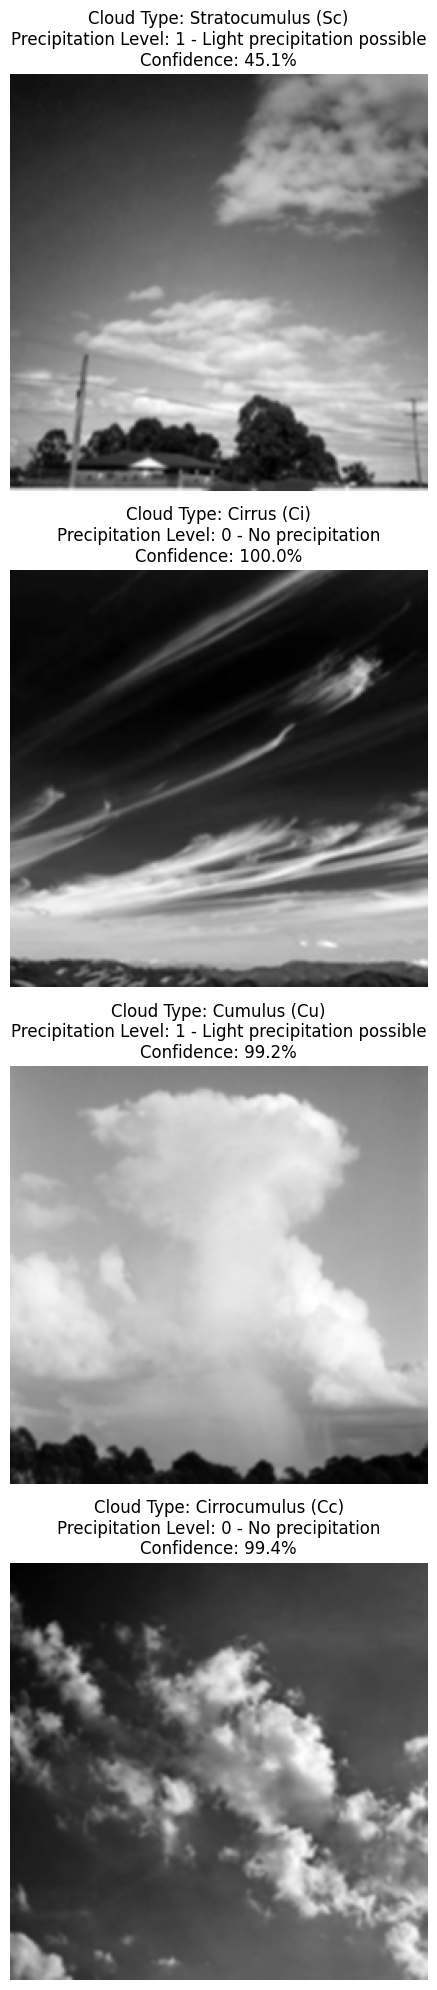

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
import pywt
import random
from sklearn.preprocessing import StandardScaler

# Configuration
class Config:
    # Directory setup - update this path to your training data location
    TRAIN_DIR = "/kaggle/working/split_data/train/npy_arrays"
    MODEL_PATH = 'cloud_model.tflite'  # or use the .keras model directly
    
    # Cloud type mapping
    CLOUD_TYPES = {
        "Ac": "Altocumulus",
        "As": "Altostratus",
        "Cc": "Cirrocumulus",
        "Cs": "Cirrostratus",
        "Ci": "Cirrus",
        "Cb": "Cumulonimbus",
        "Cu": "Cumulus",
        "Ns": "Nimbostratus",
        "Sc": "Stratocumulus",
        "St": "Stratus"
    }
    
    # Precipitation class descriptions
    PRECIP_LEVELS = {
        0: "No precipitation",
        1: "Light precipitation possible",
        2: "Moderate precipitation likely",
        3: "Heavy precipitation"
    }
    
    # Number of images to display
    NUM_DISPLAY = 4

# Function to extract wavelet features (same as in the model)
def extract_wavelet_features(image, wavelet='db4', level=3):
    if len(image.shape) == 3:
        image = np.mean(image, axis=-1)
    # Normalize image values between 0 and 1
    image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-8)
    coeffs = pywt.wavedec2(image, wavelet=wavelet, level=level)
    all_features = []
    cA = coeffs[0]
    all_features.append(cA.flatten())
    all_features.append(np.array([np.mean(cA), np.std(cA), np.median(cA), np.max(cA), np.min(cA), np.sum(cA**2)]))
    for i in range(1, len(coeffs)):
        (cH, cV, cD) = coeffs[i]
        for c in [cH, cV, cD]:
            all_features.append(c.flatten())
            all_features.append(np.array([np.mean(c), np.std(c), np.median(c), np.max(c), np.min(c), np.sum(c**2)]))
    all_features = [arr.flatten() for arr in all_features]
    return np.concatenate(all_features)

# Function to precompute scaler based on a subset of training images
def compute_scaler(train_dir, sample_size=100):
    features_list = []
    all_files = []
    
    # Collect all file paths
    for cloud_folder in os.listdir(train_dir):
        cloud_path = os.path.join(train_dir, cloud_folder)
        if os.path.isdir(cloud_path):
            for file in os.listdir(cloud_path):
                if file.endswith('.npy'):
                    all_files.append(os.path.join(cloud_path, file))
    
    # Sample a subset
    if len(all_files) > sample_size:
        sampled_files = random.sample(all_files, sample_size)
    else:
        sampled_files = all_files
    
    # Extract features
    for file_path in sampled_files:
        try:
            img = np.load(file_path)
            features = extract_wavelet_features(img)
            features_list.append(features)
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    # Create and fit the scaler
    features_array = np.array(features_list)
    scaler = StandardScaler()
    scaler.fit(features_array)
    return scaler

# Function to load TFLite model
def load_tflite_model(model_path):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    return interpreter, input_details, output_details

# Function to get prediction from TFLite model
def predict_with_tflite(interpreter, input_details, output_details, input_data):
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return output_data

# Function to get cloud type and precipitation level from filename
def get_cloud_info(filename):
    # Extract cloud code from the filename (e.g., "Ac_0123.npy")
    cloud_code = filename.split('_')[0]
    
    # Determine precipitation level based on cloud type
    precip_mapping = {
        "Ac": 1, "As": 1, "Cc": 0, "Cs": 0, "Ci": 0,
        "Cb": 3, "Cu": 1, "Ns": 2, "Sc": 1, "St": 1
    }
    
    precip_level = precip_mapping.get(cloud_code, -1)
    
    return cloud_code, precip_level

# Main visualization function
def visualize_cloud_predictions():
    # Try to load the model
    try:
        if os.path.exists(Config.MODEL_PATH):
            print(f"Loading TFLite model from {Config.MODEL_PATH}")
            interpreter, input_details, output_details = load_tflite_model(Config.MODEL_PATH)
            model_loaded = True
        else:
            print(f"Model file not found at {Config.MODEL_PATH}")
            model_loaded = False
    except Exception as e:
        print(f"Error loading model: {e}")
        model_loaded = False
    
    # Compute scaler for feature normalization
    print("Computing feature scaler...")
    scaler = compute_scaler(Config.TRAIN_DIR)
    print("Scaler computed.")
    
    # Get all cloud type folders
    cloud_folders = []
    for folder in os.listdir(Config.TRAIN_DIR):
        if os.path.isdir(os.path.join(Config.TRAIN_DIR, folder)):
            cloud_folders.append(folder)
    
    # Setup the plot
    fig, axes = plt.subplots(Config.NUM_DISPLAY, 1, figsize=(10, 5*Config.NUM_DISPLAY))
    if Config.NUM_DISPLAY == 1:
        axes = [axes]
    
    # Process random images
    for i in range(Config.NUM_DISPLAY):
        # Select a random cloud folder
        folder = random.choice(cloud_folders)
        folder_path = os.path.join(Config.TRAIN_DIR, folder)
        
        # Get a random image from the folder
        files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
        if not files:
            continue
        random_file = random.choice(files)
        file_path = os.path.join(folder_path, random_file)
        
        # Load and process the image
        try:
            # Load the image
            img_array = np.load(file_path)
            
            # Get true cloud info from filename
            cloud_code, precip_level = get_cloud_info(random_file)
            cloud_name = Config.CLOUD_TYPES.get(cloud_code, "Unknown")
            precip_desc = Config.PRECIP_LEVELS.get(precip_level, "Unknown")
            
            # Extract features and make prediction if model is loaded
            confidence = "N/A"
            if model_loaded:
                features = extract_wavelet_features(img_array)
                features = scaler.transform(np.array([features]))
                
                # Make prediction
                predictions = predict_with_tflite(interpreter, input_details, output_details, features.astype(np.float32))
                predicted_class = np.argmax(predictions[0])
                confidence = f"{predictions[0][predicted_class]*100:.1f}%"
            
            # Display the image
            axes[i].imshow(img_array, cmap='gray')
            axes[i].set_title(f"Cloud Type: {cloud_name} ({cloud_code})\n"
                             f"Precipitation Level: {precip_level} - {precip_desc}\n"
                             f"Confidence: {confidence}", fontsize=12)
            axes[i].axis('off')
            
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
            axes[i].text(0.5, 0.5, f"Error processing image: {str(e)}", 
                        horizontalalignment='center', fontsize=10)
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the visualization
if __name__ == "__main__":
    visualize_cloud_predictions()

In [14]:
# Add this to your Python training code
import numpy as np

# Collect all features from training data
all_features = []
for cloud_folder in os.listdir(Config.TRAIN_DIR):
    cloud_path = os.path.join(Config.TRAIN_DIR, cloud_folder)
    if os.path.isdir(cloud_path):
        for file in os.listdir(cloud_path):
            if file.endswith('.npy'):
                img = np.load(os.path.join(cloud_path, file))
                features = extract_wavelet_features(img)
                all_features.append(features)

# Convert to numpy array
features_array = np.array(all_features)

# Calculate mean and std for each feature
feature_means = np.mean(features_array, axis=0)
feature_stds = np.std(features_array, axis=0)

# Print or save these values
np.savetxt('feature_means.txt', feature_means)
np.savetxt('feature_stds.txt', feature_stds)